<a href="https://colab.research.google.com/github/elianramon/Challenge_3_TelecomX_2_CD_ONE/blob/main/TeleconX_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 TelecomX – Machine Learning for Churn Prediction

**Author:** Adriely Lopes  
**Dataset:** TelecomX – Processed Data (Part 1)

This project applies Machine Learning techniques to predict customer churn in a telecommunications company.

The dataset used in this analysis was previously prepared through an **ETL process (Extract, Transform, Load)**, ensuring data quality and consistency before model development.

The goal is to identify patterns associated with customer cancellation and **build predictive models capable of detecting clients at risk of leaving**. These insights can support data-driven decisions and help companies improve customer retention strategies.

🔎 **Previous Project – ETL and Data Preparation**  
[TelecomX Churn ETL Repository](https://github.com/Adrilopes/telecomx-churn-analysis)

In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import requests

___
## 1. Data Preparation

### 1.1 Loading the Processed Dataset and Initial Checks

In [70]:
import pandas as pd

response = requests.get("https://raw.githubusercontent.com/alura-cursos/challenge2-data-science/refs/heads/main/TelecomX_Data.json")
data = response.json()

data = pd.json_normalize(data)             # "Achata" o JSON para que cada chave vire uma coluna individual
data.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [71]:
data.shape

(7267, 21)

In [72]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

In [73]:
# Lista de prefixos que você deseja remover
prefixos = ['customer.', 'phone.', 'internet.', 'account.', 'Charges.']

data.columns = data.columns.str.replace(r'|'.join(prefixos), '', regex=True)

In [74]:
data.columns = data.columns.str.lower()
data.isnull().sum()

,0
d,0
churn,0
gender,0
seniorcitizen,0
partner,0
dependents,0
tenure,0
phoneservice,0
multiplelines,0
internetservice,0


In [75]:
data.dtypes

,0
d,object
churn,object
gender,object
seniorcitizen,int64
partner,object
dependents,object
tenure,int64
phoneservice,object
multiplelines,object
internetservice,object


### 1.2 Removing Irrelevant Columns for Model Training

In [76]:
data = data.drop(columns="d")

In [77]:
data.shape

(7267, 20)

### 1.3 Encoding Categorical Variable

In [78]:
data.select_dtypes(include="object").columns

Index(['churn', 'gender', 'partner', 'dependents', 'phoneservice',
       'multiplelines', 'internetservice', 'onlinesecurity', 'onlinebackup',
       'deviceprotection', 'techsupport', 'streamingtv', 'streamingmovies',
       'contract', 'paperlessbilling', 'paymentmethod', 'total'],
      dtype='object')

In [79]:
data["onlinesecurity"] = data["onlinesecurity"].map({"Yes":1,"No":0})

In [80]:
categorical_cols = [
    "gender",
    "internetservice",
    "contract",
    "paymentmethod"
]

# One-Hot Encoding
df_encoded = pd.get_dummies(data, columns=categorical_cols, drop_first=True, dtype=int)

In [81]:
df_encoded.shape

(7267, 24)

In [82]:
df_encoded.dtypes

,0
churn,object
seniorcitizen,int64
partner,object
dependents,object
tenure,int64
phoneservice,object
multiplelines,object
onlinesecurity,float64
onlinebackup,object
deviceprotection,object


In [83]:
df_encoded.isnull().sum().sum()

np.int64(1581)

### 1.4 Analyzing the Class Distribution of Churn

In [84]:
churn_counts = df_encoded["churn"].value_counts()
churn_proportions = df_encoded['churn'].value_counts(normalize=True).mul(100)

print(churn_counts)
print(churn_proportions)

churn
No     5174
Yes    1869
        224
Name: count, dtype: int64
churn
No     71.198569
Yes    25.719004
        3.082427
Name: proportion, dtype: float64


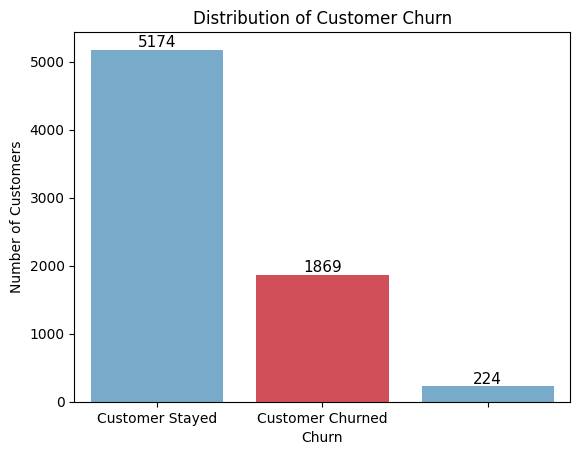

In [85]:
import seaborn as sns
import matplotlib.pyplot as plt

ax = sns.countplot(
    x="churn",
    hue="churn",
    data=df_encoded,
    palette=["#6BAED6", "#E63946"],
    legend=False
)

ax.set_xticklabels(["Customer Stayed", "Customer Churned"])

for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='bottom',
        fontsize=11
    )

plt.title("Distribution of Customer Churn")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

### 1.4.1 Handling Class Imbalance (Optional)

In [86]:
import sys
import os

sys.path.append(os.path.abspath("."))


In [87]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# --- DEFINIÇÃO DAS FUNÇÕES ---

def split_data(df: pd.DataFrame):
    # Removendo colunas que não são features (alvo e status)
    # Usei .lower() para garantir que bata com o que mudamos antes
    X = df.drop(["churn", "churn status"], axis=1, errors="ignore")
    y = df["churn"]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )
    return X_train, X_test, y_train, y_test

def apply_smote(X_train, y_train):
    smote = SMOTE(random_state=42)
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
    return X_train_resampled, y_train_resampled

def scale_data(X_train, X_test):
    scaler = StandardScaler()
    # O scaler aprende (fit) no treino e apenas aplica (transform) no teste
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    return X_train_scaled, X_test_scaled

In [88]:
# --- EXECUÇÃO DO PIPELINE ---

# 1. Divide os dados (use o seu dataframe que já passou pelo One-Hot Encoding)
X_train, X_test, y_train, y_test = split_data(df_encoded)

# 2. Aplica o SMOTE para balancear as classes (apenas no treino!)
X_train_resampled, y_train_resampled = apply_smote(X_train, y_train)

# 3. Normaliza os dados (coloca tudo na mesma escala numérica)
X_train_scaled, X_test_scaled = scale_data(X_train_resampled, X_test)

print("Processamento concluído com sucesso!")
print(f"Formato do treino após SMOTE: {X_train_resampled.shape}")

ValueError: could not convert string to float: 'Yes'

In [ ]:
print("Original training distribution:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_resampled.value_counts())

### 1.5 Feature Scaling for Machine Learning Models

In [ ]:
import warnings
warnings.filterwarnings("ignore")

# Logistic Regression + GridSearch
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

log_reg_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('log_reg', LogisticRegression(random_state=42, max_iter=1000))
])

param_grid_log = {
    'log_reg__C': [0.01, 0.1, 1, 10],
    'log_reg__penalty': ['l2'],
    'log_reg__solver': ['lbfgs', 'saga']
}

grid_log = GridSearchCV(log_reg_pipeline, param_grid_log, cv=5, scoring='f1')
grid_log.fit(X_train_resampled, y_train_resampled)

print('Best parameters - Logistic Regression:', grid_log.best_params_)

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import seaborn as sns
import matplotlib.pyplot as plt

# Predictions on the test dataset
y_pred = grid_log.predict(X_test)

# Main evaluation metrics
print("Model Performance Metrics:")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")
print(f"F1-score: {f1_score(y_test, y_pred):.4f}")

# Detailed classification report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Churn', 'Churn'],
    yticklabels=['No Churn', 'Churn']
)

plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Insights

Due to the class imbalance in the dataset, accuracy alone is not sufficient to properly evaluate model performance.

Therefore, additional metrics such as Precision, Recall, and F1-score were analyzed, as they provide a more complete understanding of the model’s ability to correctly identify customers who are likely to churn.

**The model achieved a recall of approximately 0.71 for the churn class**, indicating that it is capable of identifying a significant portion of customers at risk of leaving.

___
## 2. Correlation and Feature Selection

### 2.1 Correlation Analysis

In [ ]:
# Numerical variables selected for correlation analysis
numerical_cols = [
    'tenure',
    'charges_monthly',
    'charges_total'
]

# Correlation matrix
corr_matrix = df_encoded[numerical_cols + ['churn']].corr()

In [ ]:
plt.figure(figsize=(6,4))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Numerical Features")
plt.show()

### 2.2 Targeted Analysis of Key Variables

### 2.2.1 Contract Tenure × Churn

In [ ]:
df_encoded["Churn Status"] = df_encoded["churn"].map({0:"Customer Stayed", 1:"Customer Churned"})

In [ ]:
plt.figure(figsize=(6,4))

sns.scatterplot(
    x="tenure",
    y="charges_total",
    hue="Churn Status",
    data=df_encoded,
    palette=["#6BAED6", "#E63946"],
    alpha=0.6
)

plt.title("Tenure vs Total Charges by Churn")
plt.xlabel("Tenure (Months)")
plt.ylabel("Total Charges")

plt.show()

### 2.2.2 Total Charges × Churn

In [ ]:
plt.figure(figsize=(6,4))

sns.boxplot(
    x="Churn Status",
    y="charges_total",
    data=df_encoded,
    palette=[ "#6BAED6", "#E63946"]
)

plt.title("Customer Total Charges by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Total Charges")

plt.show()

### Insights

Customers who churn tend to have shorter tenure and lower total charges compared to customers who remain active.

This pattern suggests that many cancellations occur during the early stages of the customer lifecycle.

Therefore, customer retention strategies should focus particularly on new customers in their first months of service.

___
## 🤖 Predictive Modeling

### 3.1 Data Splitting

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X = df_encoded.drop(["churn", "Churn Status"], axis=1)
y = df_encoded["churn"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [ ]:
print("Full dataset distribution:")
print(y.value_counts(normalize=True))

print("\nTraining set distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest set distribution:")
print(y_test.value_counts(normalize=True))

### 3.2 Model Creation
> In this stage, different machine learning models were developed to predict customer churn.
> Two algorithms were selected to compare their performance and understand how different modeling approaches behave with the dataset.

### 3.2.1 Model 1 — Logistic Regression

Logistic Regression was selected as the first model because it is widely used for binary classification problems.

Since this algorithm is sensitive to feature scale, normalization was applied to ensure that all variables contribute equally to the model.

In [ ]:
from src.train_model import train_logistic_regression

log_model = train_logistic_regression(X_train_scaled, y_train_resampled)
y_pred_log = log_model.predict(X_test_scaled)

In [ ]:
cm_log = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_log,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Customer Stayed", "Customer Churned"],
    yticklabels=["Customer Stayed", "Customer Churned"]
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### 3.2.2 Model 2 — Random Forest

Random Forest was selected as the second predictive model. This algorithm is an ensemble learning method that combines multiple decision trees to improve prediction performance.

Unlike Logistic Regression, Random Forest is not sensitive to feature scaling because it is based on decision trees that split data according to feature thresholds.

This allows the model to capture complex and non-linear relationships in the dataset without requiring normalization.

In [ ]:
from src.train_model import train_random_forest

rf_model = train_random_forest(X_train_resampled, y_train_resampled)

y_pred_rf = rf_model.predict(X_test)

In [ ]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Reds",
    xticklabels=["Customer Stayed", "Customer Churned"],
    yticklabels=["Customer Stayed", "Customer Churned"]
)

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### 3.2.3 Model Evaluation

In [ ]:
from src.evaluate_model import evaluate_model

log_results = evaluate_model(log_model, X_test_scaled, y_test)
rf_results = evaluate_model(rf_model, X_test, y_test)

print("=== Accuracy ===")
print("Logistic Regression:", log_results["accuracy"])
print("Random Forest:", rf_results["accuracy"])

print("\n=== Classification Report ===")

print("\nLogistic Regression:")
print(log_results["report"])

print("\nRandom Forest:")
print(rf_results["report"])

**Logistic Regression achieved better performance** in detecting churn cases, showing higher recall for the churn class.

Random Forest produced slightly more conservative predictions, resulting in fewer churn detections but also fewer false positives.

Overall, the results suggest that churn behavior in this dataset follows relatively linear patterns related to contract duration and billing characteristics. Because of this, Logistic Regression slightly outperformed Random Forest, as these relationships can be effectively captured by a linear model.

## 3.2.4 ROC Curve

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Probabilidades
y_prob_log = log_model.predict_proba(X_test_scaled)[:,1]
y_prob_rf = rf_model.predict_proba(X_test)[:,1]

# ROC
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

# AUC
auc_log = roc_auc_score(y_test, y_prob_log)
auc_rf = roc_auc_score(y_test, y_prob_rf)

plt.figure(figsize=(7,5))

plt.plot(fpr_log, tpr_log, label=f'Logistic Regression (AUC={auc_log:.2f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC={auc_rf:.2f})')

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()

plt.show()

### ROC Curve Analysis

Both models demonstrated good predictive performance, with AUC scores above 0.80.

Logistic Regression achieved a slightly higher AUC (0.83) compared to Random Forest (0.82), indicating a marginally better ability to distinguish between customers who churn and those who remain.

Overall, the results suggest that both models are effective for churn prediction, with Logistic Regression providing slightly stronger discrimination.

### Overfitting and Underfitting

No clear signs of overfitting or underfitting were observed. Both models achieved similar performance on the test data, indicating that they generalize reasonably well to unseen observations.

Logistic Regression showed slightly better performance, with a marginally higher AUC score and better detection of churn cases.

Random Forest produced comparable results, although with slightly lower performance. This may be related to the use of default hyperparameters, and further tuning could potentially improve the model.

___
## 4. Feature Importance Analysis

## 4.1 Logistic Regression Feature Importance

In [ ]:
import pandas as pd

log_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": log_model.coef_[0]
})

log_importance["Abs_Coefficient"] = log_importance["Coefficient"].abs()

log_importance = log_importance.sort_values(by="Abs_Coefficient", ascending=False)

log_importance.head(10)

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.barplot(
    x="Coefficient",
    y="Feature",
    data=log_importance.head(10),
    palette="viridis"
)

plt.title("Top Features Influencing Churn (Logistic Regression)")
plt.show()

## 4.2 Random Forest Feature Importance

In [ ]:
rf_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

rf_importance = rf_importance.sort_values(by="Importance", ascending=False)

rf_importance.head(10)

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="Importance",
    y="Feature",
    data=rf_importance.head(10),
    palette="coolwarm"
)

plt.title("Top Features Influencing Churn (Random Forest)")
plt.show()

### Key Insights

The feature importance analysis revealed that variables related to tenure, total charges, and monthly charges play a significant role in predicting customer churn.

Customers with shorter tenure and higher service costs tend to have a higher probability of leaving the service. Contract type also plays an important role, as longer contracts significantly reduce the likelihood of churn.

These insights can help companies design targeted retention strategies for customers who show higher churn risk.

___
## 📌 Conclusion – TelecomX Churn Prediction

In this project, the exploratory analysis conducted in Part 1 was extended by developing predictive models to identify customers with a higher risk of churn. The goal was to transform descriptive insights into predictive solutions that support data-driven decision making.

The results confirmed previous findings that financial and time-related variables are the main drivers of customer churn. Customer tenure, total charges, and monthly charges were identified as the most influential variables across the evaluated models.

Among the models tested, Logistic Regression achieved slightly better performance, demonstrating a strong ability to generalize to unseen data. Random Forest also performed well, producing comparable results, although the dataset appears to follow relatively linear patterns that are effectively captured by Logistic Regression.

### 🎯 Strategic Recommendations

Based on the analysis, the following strategies could help reduce customer churn:

* Focus retention efforts on customers in the early months of their contracts;

* Encourage long-term contracts through incentives or loyalty benefits;

* Monitor customers with higher monthly charges who may present greater churn risk;

* Promote automatic payment methods to improve customer retention;

* Integrate predictive models into decision-making processes to proactively identify customers at risk.

By combining exploratory analysis with predictive modeling, this project demonstrates how data can be transformed into strategic insights that support customer retention and improve long-term business performance.